# Где дешевле жить? Предсказание цен в Airbnb - учимся генерировать признаки и интерпретировать результаты модели

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Настройки визуализации
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Часть 1. Загрузка данных

In [3]:
df = pd.read_csv('AB_NYC_2019.csv')
display(df.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Удаление ненужных данных

In [4]:
drop_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
display(df.head())

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


2. Базовые статистики и распределения

In [5]:
print("Описательная статистика:")
display(df.describe())

Описательная статистика:


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
print("Пропуски:")
print(df.isnull().sum())

Пропуски:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [8]:
# Заполним 0 количество отзывов в месяц (если пропуск)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [9]:
# Удаление дубликатов
initial_shape = df.shape
df = df.drop_duplicates()
print(f"Удалено дубликатов: {initial_shape[0] - df.shape[0]}")

Удалено дубликатов: 0


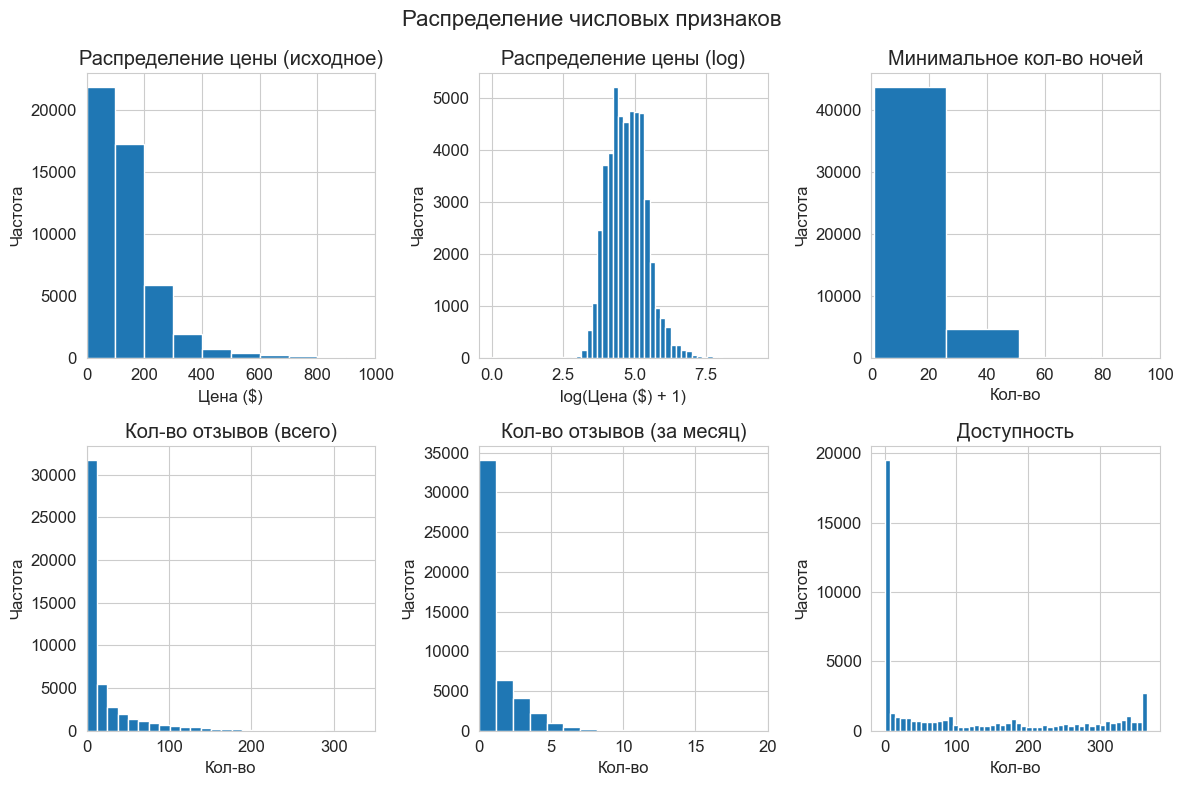

In [10]:
fig, axes = plt.subplots(2, 3)

# Цена
axes[0,0].hist(df['price'], bins=100)
axes[0,0].set_title('Распределение цены (исходное)')
axes[0,0].set_xlabel('Цена ($)')
axes[0,0].set_ylabel('Частота')
axes[0,0].set_xlim(0, 1000)

# Логарифм цены
log_price = np.log1p(df['price'])
axes[0,1].hist(log_price, bins=50)
axes[0,1].set_title('Распределение цены (log)')
axes[0,1].set_xlabel('log(Цена ($) + 1)')
axes[0,1].set_ylabel('Частота')

# Минимальные ночи
axes[0,2].hist(df['minimum_nights'], bins=50)
axes[0,2].set_title('Минимальное кол-во ночей')
axes[0,2].set_xlabel('Кол-во')
axes[0,2].set_ylabel('Частота')
axes[0,2].set_xlim(0, 100)

# Количество отзывов
axes[1,0].hist(df['number_of_reviews'], bins=50)
axes[1,0].set_title('Кол-во отзывов (всего)')
axes[1,0].set_xlabel('Кол-во')
axes[1,0].set_ylabel('Частота')
axes[1,0].set_xlim(0, 350)

# Отзывов в месяц
axes[1,1].hist(df['reviews_per_month'], bins=50)
axes[1,1].set_title('Кол-во отзывов (за месяц)')
axes[1,1].set_xlabel('Кол-во')
axes[1,1].set_ylabel('Частота')
axes[1,1].set_xlim(0, 20)

# Доступность
axes[1,2].hist(df['availability_365'], bins=50)
axes[1,2].set_title('Доступность')
axes[1,2].set_xlabel('Кол-во')
axes[1,2].set_ylabel('Частота')

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

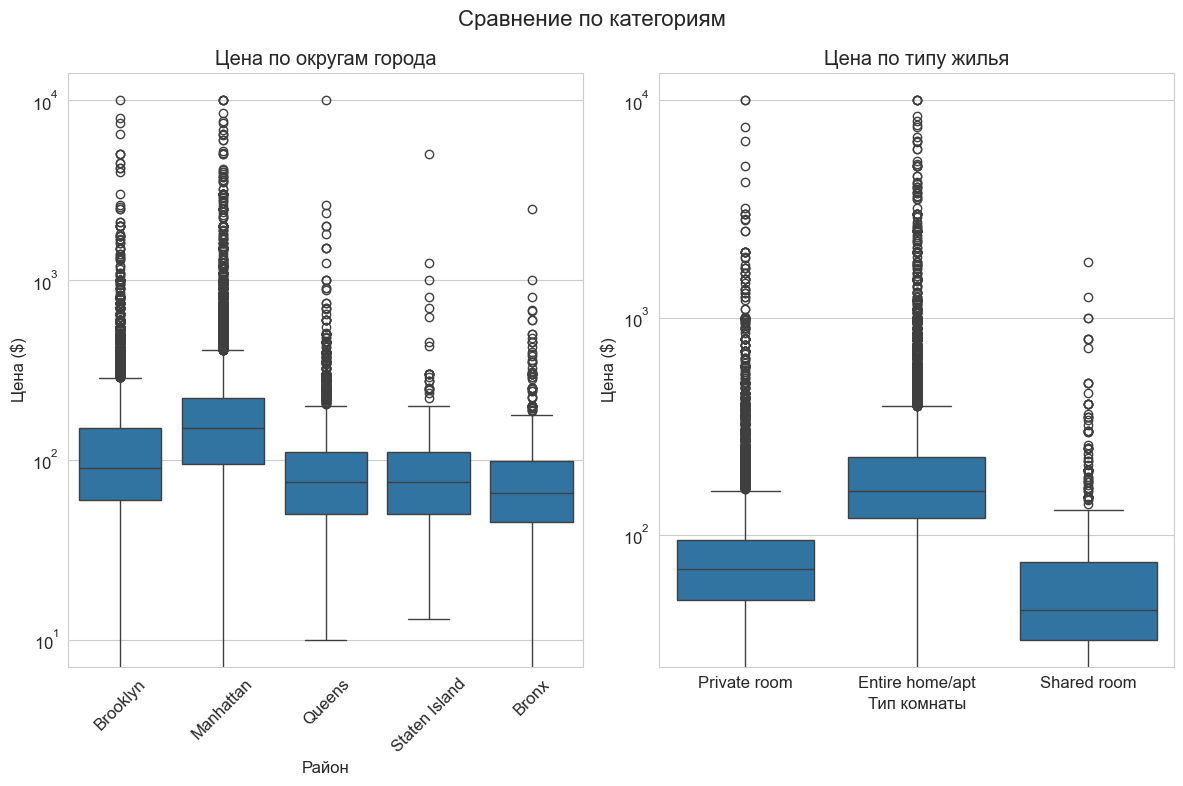

In [11]:
fig, axes = plt.subplots(1, 2)

# Boxplot по районам
sns.boxplot(data=df, x='neighbourhood_group', y='price', ax=axes[0])
axes[0].set_title('Цена по округам города')
axes[0].set_xlabel('Район')
axes[0].set_ylabel('Цена ($)')
axes[0].set_yscale('log')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot по типу комнаты
sns.boxplot(data=df, x='room_type', y='price', ax=axes[1])
axes[1].set_title('Цена по типу жилья')
axes[1].set_xlabel('Тип комнаты')
axes[1].set_ylabel('Цена ($)')
axes[1].set_yscale('log')

plt.suptitle('Сравнение по категориям', fontsize=16)
plt.tight_layout()
plt.show()

Матрица корреляций

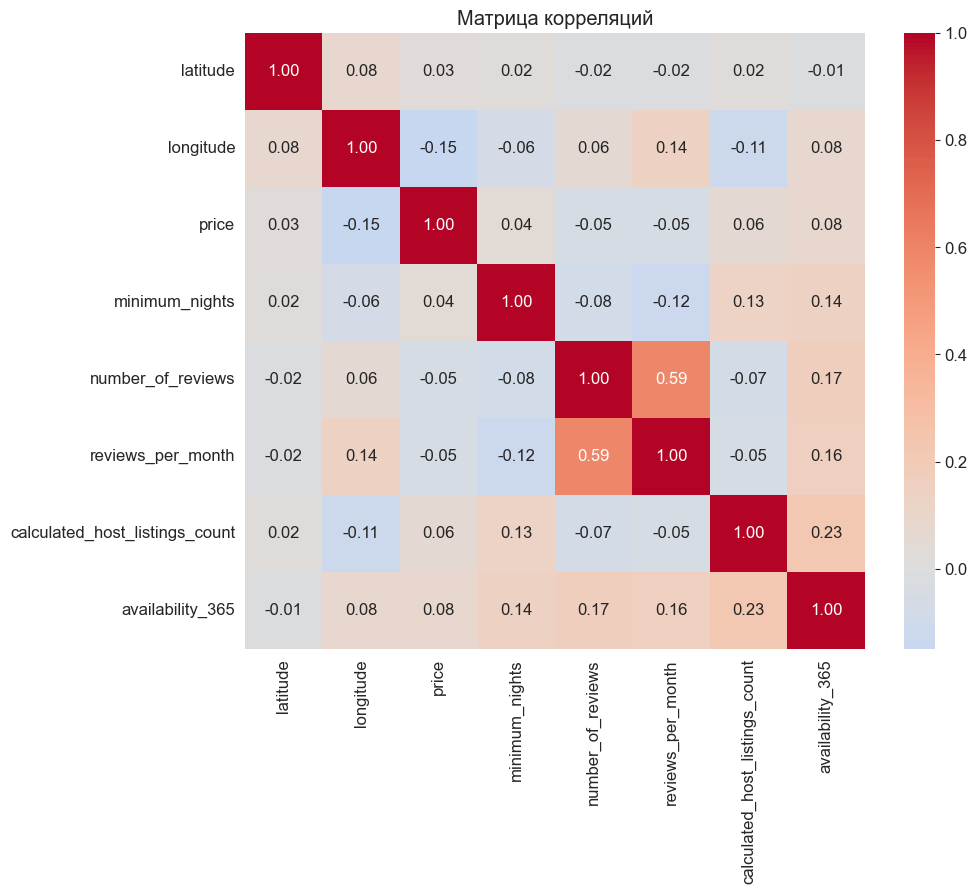

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матрица корреляций')
plt.show()

Pair plots

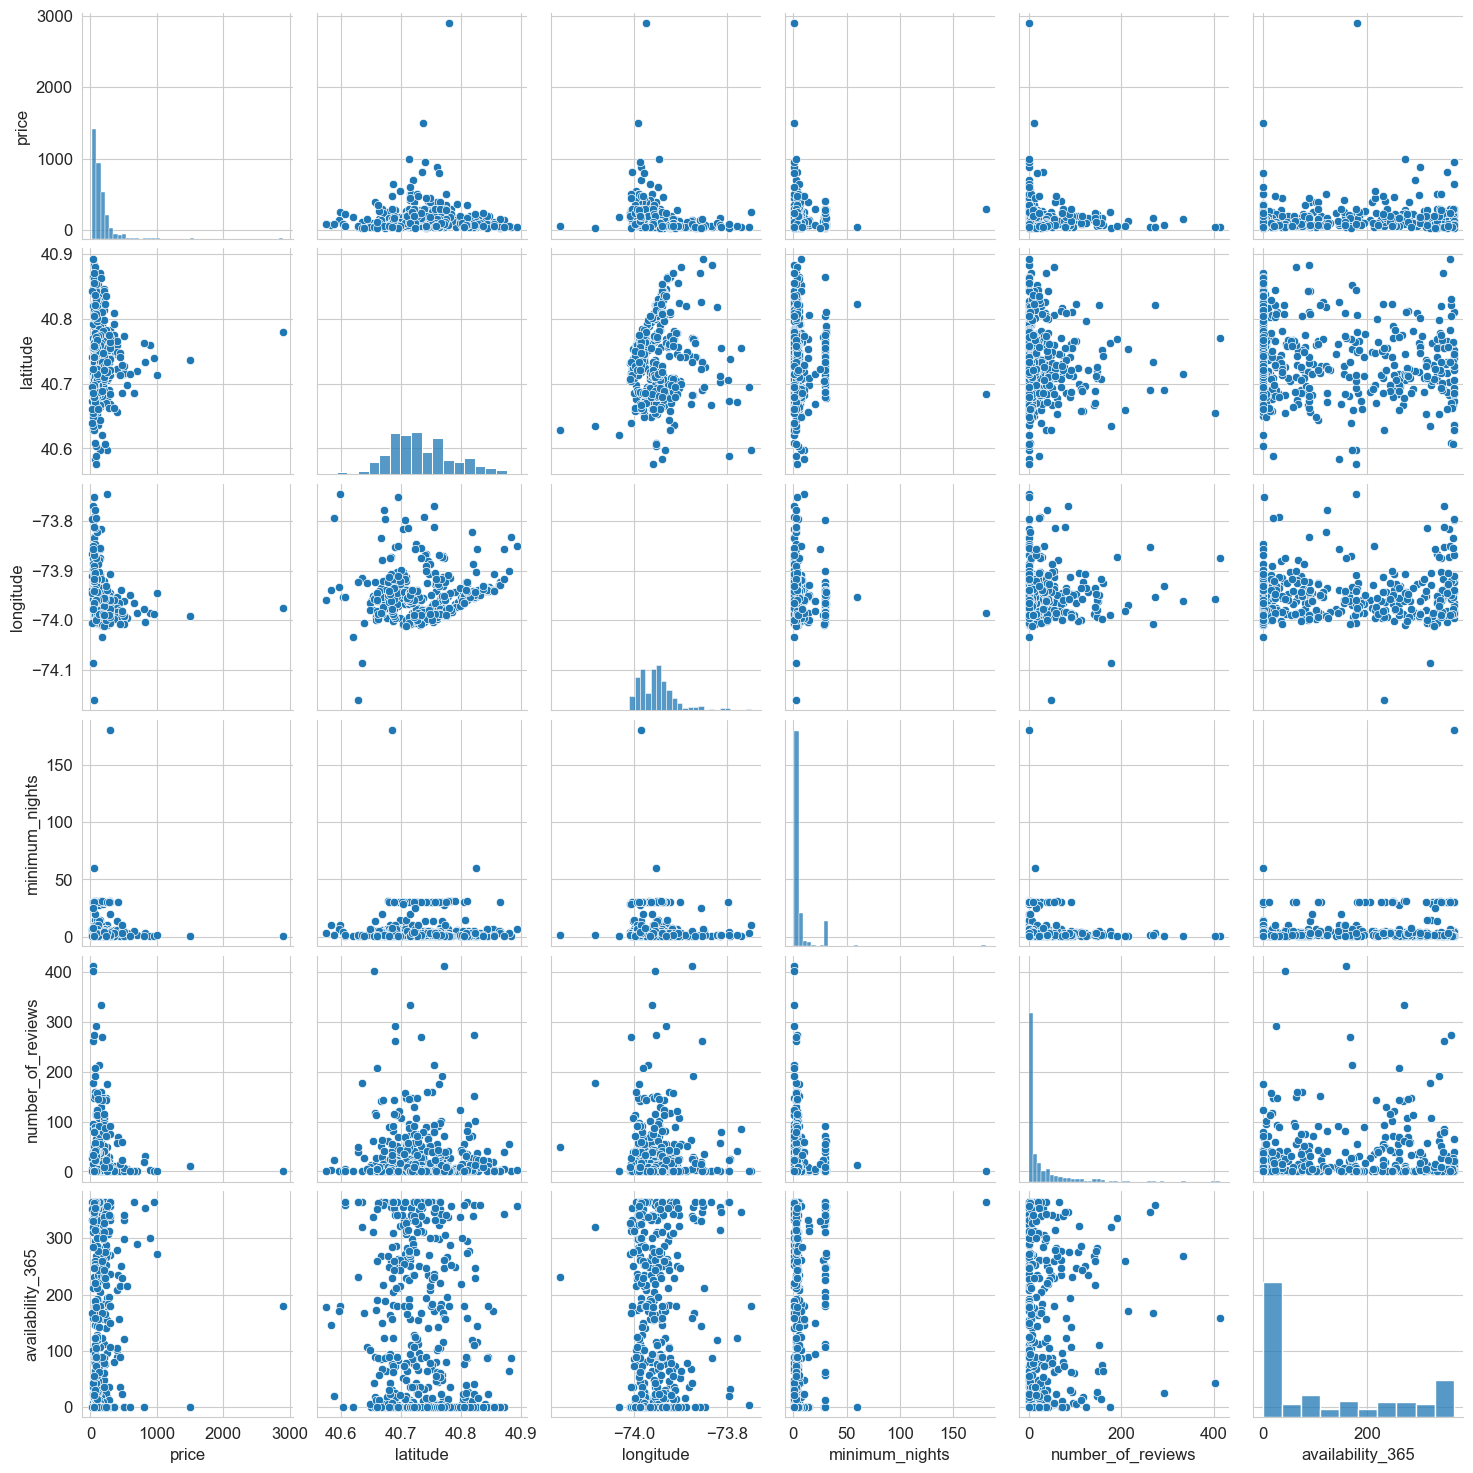

In [13]:
sns.pairplot(df[['price', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'availability_365']].sample(500))
plt.show()

Удаление аномалий

In [14]:
# Удалим экстремальные цены (>1000 $)
df = df[df['price'] <= 1000].copy()
# Удалим minimum_nights > 365
df = df[df['minimum_nights'] <= 365].copy()

print(f"Размер после удаления аномалий: {df.shape}")

Размер после удаления аномалий: (48642, 11)


Часть 2. Preprocessing & Feature Engineering

In [15]:
# Импорт библиотек
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [16]:
def distance_to_manhattan(lat, lon):
    """Евклидово расстояние до центра Манхэттена"""
    return np.sqrt((lat - manhattan_center[0])**2 + (lon - manhattan_center[1])**2)

In [17]:
# Создаем новые признаки
manhattan_center = (40.7831, -73.9712)
# Расстояние до центра Манхэттена (40.7831, -73.9712)
df['dist_to_manhattan'] = distance_to_manhattan(df['latitude'], df['longitude'])
# Логарифмирование целевой переменной, так как распределение неравномерное
df['log_price'] = np.log1p(df['price'])
# Убираем ненужные данные - price и log_price целевые, neighbourhood - слишком много районов, оставляем только округа
X = df.drop(['price', 'log_price', 'neighbourhood'], axis=1)
y = df['log_price']
print(f"Признаки после подготовки: {X.columns.tolist()}")

Признаки после подготовки: ['neighbourhood_group', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'dist_to_manhattan']


In [18]:
# Разделяем на train/test (30% тест)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Определение типов признаков
categorical_features = ['neighbourhood_group', 'room_type']
numeric_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
                    'dist_to_manhattan']

In [19]:
# Предобработка данных: OneHotEncoder + RobustScaler
# RobustScaler так как устойчив к выбросам больших чисел
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
])

Часть 3. Моделирование

In [21]:
models = {
    'LinearRegression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas=np.logspace(-3, 3, 10)),
    'LassoCV': LassoCV(alphas=np.logspace(-3, 3, 10), random_state=42, max_iter=10000),
    'ElasticNetCV': ElasticNetCV(alphas=np.logspace(-3, 3, 10), l1_ratio=[.1, .5, .7, .9, .95, .99, 1], random_state=42, max_iter=10000)
}

In [27]:
results = {}
feature_importance = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Метрики
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}

    if hasattr(pipeline.named_steps['regressor'], 'coef_'):
        cat_features = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
        all_features = numeric_features + list(cat_features)
        coefs = pipeline.named_steps['regressor'].coef_
        feature_importance[name] = pd.Series(coefs, index=all_features)

# Сравнение результатов
results_df = pd.DataFrame(results).T
print("Сравнение моделей:")
print(results_df)

Сравнение моделей:
                        R2       MAE      RMSE
LinearRegression  0.529529  0.338953  0.452410
RidgeCV           0.529526  0.338952  0.452412
LassoCV           0.528008  0.339314  0.453141
ElasticNetCV      0.528943  0.339089  0.452692


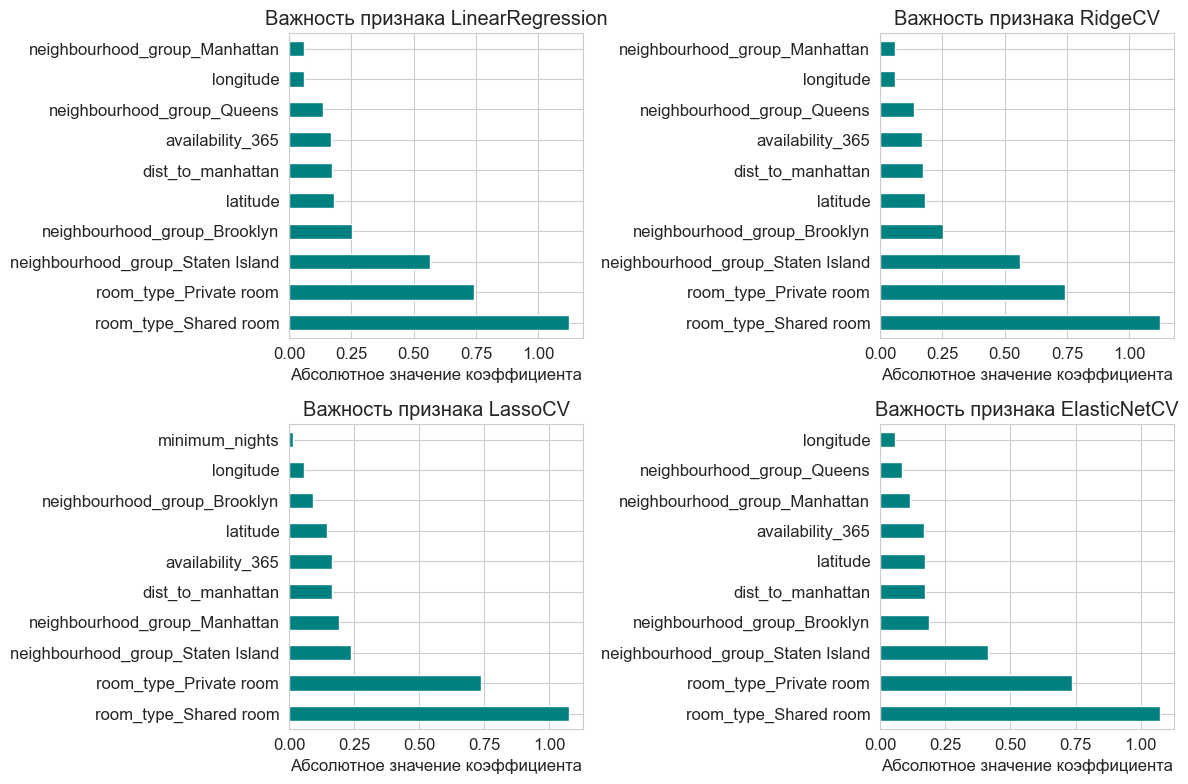

In [30]:
# Визуализация важности признаков
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()

for idx, (name, importance) in enumerate(feature_importance.items()):
    imp_sorted = importance.abs().sort_values(ascending=False).head(10)
    imp_sorted.plot(kind='barh', ax=axes[idx], color='teal')
    axes[idx].set_title(f'Важность признака {name}')
    axes[idx].set_xlabel('Абсолютное значение коэффициента')

plt.tight_layout()
plt.show()

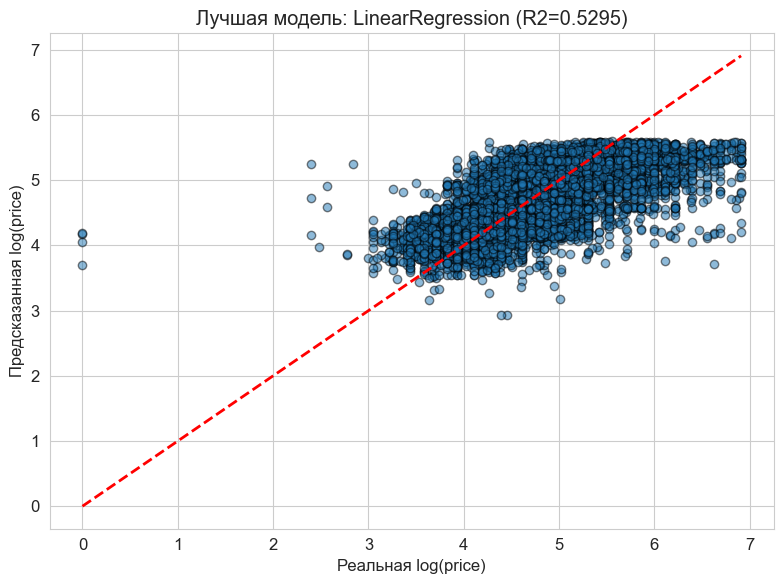

In [33]:
# График предсказанных vs реальных значений
best_model_name = results_df['R2'].idxmax()
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', models[best_model_name])
])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Реальная log(price)')
plt.ylabel('Предсказанная log(price)')
plt.title(f'Лучшая модель: {best_model_name} (R2={results_df.loc[best_model_name, "R2"]:.4f})')
plt.tight_layout()
plt.show()

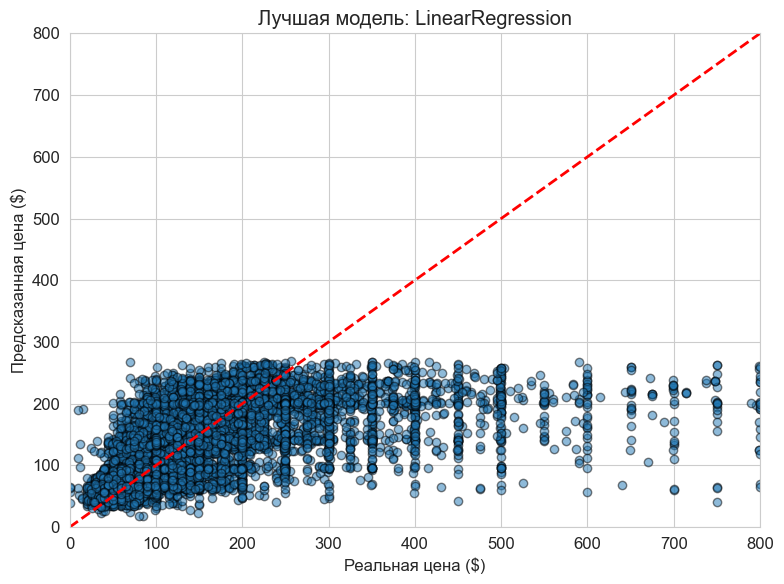

In [35]:
# Обратное преобразование для интерпретации, предскажем реальную цену а не log
y_pred_price = np.expm1(y_pred_best)
y_test_price = np.expm1(y_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_price, y_pred_price, alpha=0.5, edgecolors='k')
plt.plot([0, 1000], [0, 1000], 'r--', lw=2)
plt.xlabel('Реальная цена ($)')
plt.ylabel('Предсказанная цена ($)')
plt.title(f'Лучшая модель: {best_model_name}')
plt.xlim(0, 800)
plt.ylim(0, 800)
plt.tight_layout()
plt.show()

In [37]:
# Дополнительная метрика в реальной шкале
mae_price = mean_absolute_error(y_test_price, y_pred_price)
rmse_price = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
print(f"Метрики в исходной шкале цены (лучшая модель {best_model_name}):")
print(f"MAE = ${mae_price:.2f}")
print(f"RMSE = ${rmse_price:.2f}")

Метрики в исходной шкале цены (лучшая модель LinearRegression):
MAE = $50.27
RMSE = $94.76


1. Распределение цены имело ярко выраженный длинный правый хвост, поэтому сделали логарифмирование целевой переменной
2. Добавлили расстояние до Манхэттена, что улучшило качество (признак оказался значимым)
3. Удалили аномалии, такие как объекты с ценой > 1000$ и minimum_nights > 365
4. Использовали RobustScaler вместо StandardScaler, так как он менее чувствителен к выбросам, которые могли присутствовать в данных

5. Сравнение моделей:
    - Все четыре модели (LinearRegression, RidgeCV, LassoCV, ElasticNetCV) показали очень близкие результаты
    - LinearRegression (Обычная линейная регрессия) показала наилучший результат, линейная зависимость хорошо описала эти данные
    - Регуляризованные модели (Ridge, Lasso, ElasticNet) не смогли существенно превзойти обычную регрессию

6. Наиболее важные признаки:
   - dist_to_manhattan (чем дальше, тем дешевле)
   - room_type_Private room (отрицательный вклад)
   - neighbourhood_group_Brooklyn/Queens (отрицательный)
   - neighbourhood_group_Manhattan (положительный)

7. Метрики в логарифмической шкале:
    - R²: 0.5295. Модель объясняет около 53% дисперсии логарифма цены, что является хорошим результатом
    - MAE: 0.34. В среднем модель ошибается примерно на exp(0.34) ≈ 1.4 раза
    - RMSE: 0.45. Незначительно выше MAE, что указывает на наличие некоторых ошибок с большим отклонением

8. Метрики в исходной шкале:
    - MAE: $50.27. В среднем предсказанная цена отличается от реальной на 50 долларов

    - RMSE: $94.76. Более высокая ошибка указывает на то, что модель иногда может сильно ошибаться

В результате работы удалось построить интерпретируемую линейную модель, которая с приемлемой точностью (R² ~0.53, MAE ~50$) предсказывает цены на жилье Airbnb.